# Cell Type Image Classification using CNNs

In this notebook, we provide a full workflow for training and evaluation of a CNN model on the CTMC data.

## Import Data

In [ ]:
#Run to mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# path_to_zip = "/content/drive/MyDrive/semester 8/cmsc472 final project/CTMCV1.zip"
# Aditri's path:
path_to_zip  = "/content/drive/MyDrive/College/Junior Year/CMSC472/CTMCV1.zip"
# Sujal's path:
# path_to_zip = "/content/drive/MyDrive/CMSC472/CTMCV1.zip"
# Kevin's path (same as Sujal's lol):
# path_to_zip = "/content/drive/MyDrive/CMSC472/CTMCV1.zip"
!unzip "$path_to_zip"

Streaming output truncated to the last 5000 lines.
  inflating: CTMCV1/test/MDBK-run08/img1/001007.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/001869.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000536.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/001428.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000913.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000846.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000559.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000251.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000545.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/001032.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/001813.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000178.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/001283.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/001185.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000234.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000763.jpg  
  inflating: CTMCV1/test/MDBK-run08/img1/000607.jpg  
  inflating: CTMCV1/test/MDBK-r

## Setup

In the first section, we present some examples of the images we want our model to recognize, and write helper functions for later analyses.

For our purposes, the dataset is organized as follows:

Each training data is a folder named with cell line type and run (video) number, containing a folder "img1" holding all the frames for that particular run.

Below are all the mappings for filename and cell line type:

In [ ]:
mapping = {
    "U2O-S": "Human Bone Osteosarcoma",
    "RK-13": "Normal Rabbit Kidney",
    "PL1Ut": "Raccoon Uterus",
    "OK": "Opossum Kidney Cortex Proximal Tubule",
    "MDOK": "Madin-Darby Ovine Kidney",
    "MDBK": "Madin-Darby Bovine Kidney",
    "LLC-MK2": "Rhesus Monkey Kidney",
    "CV-1": "Normal African Green Monkey Kidney",
    "CRE-BAG2": "Albino Swiss Mouse Embryo Moloney Murine Leukemia Virus Transfected Cells",
    "BPAE": "Bovine Pulmonary Artery",
    "APM": "African Water Mongoose Skin",
    "A-549": "Male Human Lung Carcinoma",
    "A-10": "Embryonic Rat Thoracic Aorta Medial Layer",
    "3T3": "Albino Swiss Mouse Embryo",
}

## Visualize Data

Here we show images of two different cell lines:

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import re
from PIL import Image
from torchvision import transforms
from pathlib import Path
from torch.utils.data import Dataset
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from pathlib import Path
from PIL import Image
'''
Returns mapped name, run number, and frame number
'''
def expand_id(path):
    parts = path.strip().split("/")

    run_id = parts[-3]
    img_name = parts[-1]

    prefix, run_num = run_id.split("-run")
    name = mapping.get(prefix, prefix)
    img_num = img_name[:-4]

    return {
        "prefix": prefix,
        "name": name,
        "run_num": run_num,
        "image_num": img_num
    }

In [ ]:
'''
Plots a single frame (give the full file path)
'''
def plot_frame(filename):
  img = mpimg.imread(filename)
  plt.imshow(img)
  plt.axis('off')
  title_holder = expand_id(filename)
  plt.title(f"{title_holder['name']} Run {title_holder['run_num']} (Frame {title_holder['image_num']})")
  plt.show()

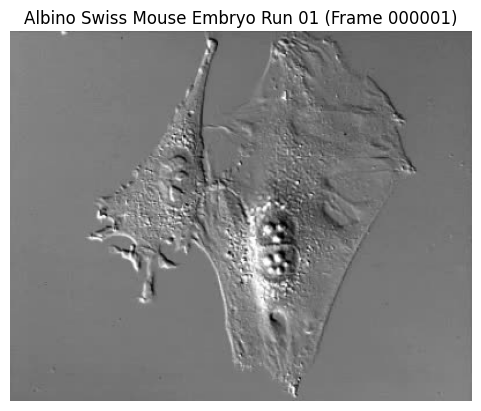

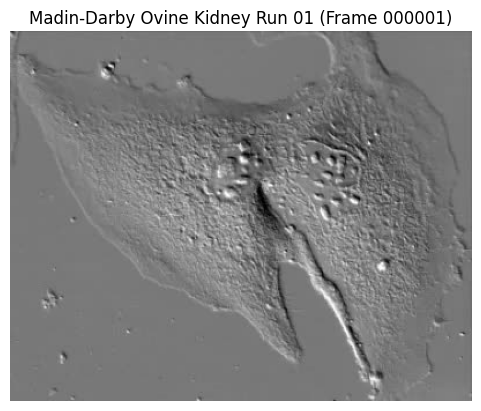

In [ ]:
plot_frame("/content/CTMCV1/train/3T3-run01/img1/000001.jpg")
plot_frame("/content/CTMCV1/train/MDOK-run01/img1/000001.jpg")

## Prepare Data

In [ ]:
img = Image.open("/content/CTMCV1/train/3T3-run01/img1/000001.jpg").convert("L")  # "L" = grayscale

transform = transforms.Compose([
    transforms.ToTensor(),
])

tensor = transform(img)

print(tensor.shape)

torch.Size([1, 320, 400])


Notes:
Get img label by running extract_id(filename)['prefix'].

Read the image with img = Image.open("/content/CTMCV1/train/3T3-run01/img1/000001.jpg").convert("L")  # "L" = grayscale


In [ ]:
# Augmentation for training, resize-only for test/val
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class CTMC(Dataset):

    def __init__(self, mode='train', transform=None, every_nth=10):
        self.root_dir = Path(f'/content/CTMCV1/{mode}')
        self.transform = transform

        # collect all image paths
        # filter only files
        all_paths = sorted([
            p for p in self.root_dir.rglob("img1/*") if p.is_file()
        ])
        # keep every nth frame (to save training time/power)
        self.image_paths = all_paths[::every_nth]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label_str = expand_id(str(img_path))['prefix']
        label = label2idx[label_str]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
'''
Label encoding
'''
label2idx = {label: i for i, label in enumerate(sorted(mapping.keys()))}
idx2label = {i: label for label, i in label2idx.items()}
NUM_CLASSES = len(label2idx)

print("Label → index mapping:")
for label, idx in label2idx.items():
    print(f"  {idx:2d}  {label:10s}  {mapping[label]}")

Label → index mapping:
   0  3T3         Albino Swiss Mouse Embryo
   1  A-10        Embryonic Rat Thoracic Aorta Medial Layer
   2  A-549       Male Human Lung Carcinoma
   3  APM         African Water Mongoose Skin
   4  BPAE        Bovine Pulmonary Artery
   5  CRE-BAG2    Albino Swiss Mouse Embryo Moloney Murine Leukemia Virus Transfected Cells
   6  CV-1        Normal African Green Monkey Kidney
   7  LLC-MK2     Rhesus Monkey Kidney
   8  MDBK        Madin-Darby Bovine Kidney
   9  MDOK        Madin-Darby Ovine Kidney
  10  OK          Opossum Kidney Cortex Proximal Tubule
  11  PL1Ut       Raccoon Uterus
  12  RK-13       Normal Rabbit Kidney
  13  U2O-S       Human Bone Osteosarcoma


In [ ]:
'''
Check for class imbalance
'''

from collections import Counter

train_dataset_raw = CTMC(mode='train', transform=None)

label_counts = Counter(
    expand_id(str(p))['prefix'] for p in train_dataset_raw.image_paths
)

print(f"{'Label':<12} {'Full name':<52} {'Frames':>7}  {'% of total':>10}")
print("-" * 85)
total = sum(label_counts.values())
for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"{label:<12} {mapping[label]:<52} {count:>7,}  {100*count/total:>9.1f}%")
print(f"\nTotal training frames: {total:,}")

Label        Full name                                             Frames  % of total
-------------------------------------------------------------------------------------
3T3          Albino Swiss Mouse Embryo                                992       12.3%
LLC-MK2      Rhesus Monkey Kidney                                     900       11.2%
MDOK         Madin-Darby Ovine Kidney                                 880       10.9%
A-10         Embryonic Rat Thoracic Aorta Medial Layer                789        9.8%
BPAE         Bovine Pulmonary Artery                                  731        9.1%
MDBK         Madin-Darby Bovine Kidney                                667        8.3%
OK           Opossum Kidney Cortex Proximal Tubule                    552        6.9%
APM          African Water Mongoose Skin                              525        6.5%
PL1Ut        Raccoon Uterus                                           505        6.3%
U2O-S        Human Bone Osteosarcoma                  

In [ ]:
'''
Calculate class weights to use in the loss function
'''

import torch

counts = torch.tensor(
    [label_counts[idx2label[i]] for i in range(NUM_CLASSES)],
    dtype=torch.float
)
class_weights = counts.sum()/(NUM_CLASSES * counts)
class_weights = class_weights/class_weights.sum() * NUM_CLASSES

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {idx2label[i]:10s}  weight = {w:.4f}")

Class weights:
  3T3         weight = 0.4449
  A-10        weight = 0.5593
  A-549       weight = 2.7581
  APM         weight = 0.8406
  BPAE        weight = 0.6037
  CRE-BAG2    weight = 1.2327
  CV-1        weight = 1.2754
  LLC-MK2     weight = 0.4903
  MDBK        weight = 0.6616
  MDOK        weight = 0.5015
  OK          weight = 0.7994
  PL1Ut       weight = 0.8738
  RK-13       weight = 1.8387
  U2O-S       weight = 1.1200


In [ ]:
'''
DataLoaders for train and test
'''

from torch.utils.data import DataLoader

BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset = CTMC(mode='train', transform=train_transform, every_nth=15)
test_dataset  = CTMC(mode='test',  transform=eval_transform,  every_nth=15)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Train batches : {len(train_loader):,}  ({len(train_dataset):,} frames)")
print(f"Test  batches : {len(test_loader):,}  ({len(test_dataset):,} frames)")

imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"Batch label range : {labels.min().item()} – {labels.max().item()}")

Train batches : 84  (5,360 frames)
Test  batches : 76  (4,808 frames)

Batch image shape : torch.Size([64, 3, 224, 224])
Batch label range : 0 – 13


# Build Model

In [ ]:
'''
Load Resnet
'''

import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def build_model(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model.to(DEVICE)

model = build_model(freeze_backbone=False)

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


Total params    : 11,183,694
Trainable params: 11,183,694


In [ ]:
'''
Write loss, optimizer, and learning rate scheduler
'''

import torch.optim as optim

NUM_EPOCHS  = 20
LR_BACKBONE = 1e-4
LR_HEAD     = 1e-3

criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

head_params     = list(model.fc.parameters())
head_param_ids  = set(id(p) for p in head_params)
backbone_params = [p for p in model.parameters() if id(p) not in head_param_ids]

optimizer = optim.Adam([
    {"params": backbone_params, "lr": LR_BACKBONE, "weight_decay": 1e-4},
    {"params": head_params, "lr": LR_HEAD, "weight_decay": 1e-4},
])

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"Criterion : {criterion}")
print(f"Optimizer : Adam  (backbone lr={LR_BACKBONE}, head lr={LR_HEAD})")
print(f"Scheduler : CosineAnnealingLR over {NUM_EPOCHS} epochs")

Criterion : CrossEntropyLoss()
Optimizer : Adam  (backbone lr=0.0001, head lr=0.001)
Scheduler : CosineAnnealingLR over 20 epochs


# Train Model

## Hyperparameters to tune
* every_nth = how much data we train on (every nth frame)
* NUM_EPOCHS
* weight_decay in the optimizer
* Dropout(p=...) in model.fc
* label_smoothing in the criterion

In [ ]:
'''
Train helper (one epoch)
'''

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)

    return total_loss / total, correct / total

In [ ]:
'''
Training loop
'''
import os
CHECKPOINT_DIR  = "/content/drive/MyDrive/cmsc472_checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_test_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    test_loss,  test_acc  = eval_epoch(model, test_loader,  criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    # Save checkpoint if this is the best test accuracy so far
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save({
            "epoch":      epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "test_acc":   test_acc,
            "test_loss":  test_loss,
        }, CHECKPOINT_PATH)
        flag = "  ✓ saved"
    else:
        flag = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}"
        f"  train loss {train_loss:.4f}  acc {train_acc:.3f}"
        f"  |  test loss {test_loss:.4f}  acc {test_acc:.3f}"
        f"{flag}"
    )

print(f"\nBest test accuracy: {best_test_acc:.4f}")

Epoch 01/20  train loss 0.8806  acc 0.729  |  test loss 0.9087  acc 0.733  ✓ saved
Epoch 02/20  train loss 0.0923  acc 0.975  |  test loss 1.1212  acc 0.694
Epoch 03/20  train loss 0.0348  acc 0.992  |  test loss 0.8258  acc 0.783  ✓ saved
Epoch 04/20  train loss 0.0241  acc 0.994  |  test loss 1.0338  acc 0.723
Epoch 05/20  train loss 0.0150  acc 0.996  |  test loss 0.9726  acc 0.764
Epoch 06/20  train loss 0.0133  acc 0.997  |  test loss 1.0160  acc 0.759
Epoch 07/20  train loss 0.0115  acc 0.997  |  test loss 1.0032  acc 0.765
Epoch 08/20  train loss 0.0068  acc 0.999  |  test loss 0.8856  acc 0.769
Epoch 09/20  train loss 0.0064  acc 0.999  |  test loss 0.8883  acc 0.759
Epoch 10/20  train loss 0.0052  acc 0.998  |  test loss 1.3644  acc 0.719
Epoch 11/20  train loss 0.0044  acc 0.998  |  test loss 1.0655  acc 0.742
Epoch 12/20  train loss 0.0036  acc 0.999  |  test loss 0.9156  acc 0.765
Epoch 13/20  train loss 0.0026  acc 1.000  |  test loss 1.0482  acc 0.749
Epoch 14/20  train l

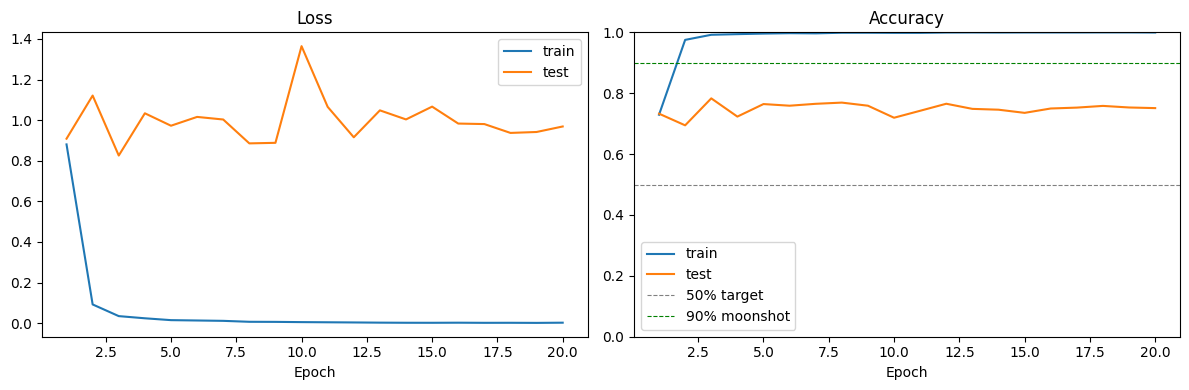

In [ ]:
'''
Plot training curves
'''

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history["train_loss"], label="train")
ax1.plot(epochs, history["test_loss"],  label="test")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="train")
ax2.plot(epochs, history["test_acc"],  label="test")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="50% target")
ax2.axhline(0.9, color="green", linestyle="--", linewidth=0.8, label="90% moonshot")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "training_curves.png"), dpi=150)
plt.show()

# Hyperparameter Experiments

We run the model with several different hyperparameter configurations and compare their
test accuracy, macro F1, and macro AUROC so we can reason about what settings work best.
Each configuration re-initialises the model and dataloaders from scratch to ensure fair comparison.
The best checkpoint from each run is saved under its own name in `CHECKPOINT_DIR`.

In [ ]:
'''
Hyperparameter sweep — compare multiple configurations
Each config is run N_RUNS times with different seeds; mean ± std dev is reported.
Set N_RUNS=1 to save compute (results will have no std dev).
'''

import os, copy
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score
import torch.nn.functional as F

SEED   = 42   # base seed; each run offsets by run index
N_RUNS = 3    # runs per config — increase for tighter estimates, decrease to save compute

CONFIGS = [
    {
        "name":          "baseline",
        "every_nth":     15,
        "num_epochs":    5,
        "weight_decay":  1e-4,
        "dropout":       0.5,
        "label_smooth":  0.0,
    },
    {
        "name":          "every_nth",
        "every_nth":     10,
        "num_epochs":    5,
        "weight_decay":  1e-4,
        "dropout":       0.5,
        "label_smooth":  0.0,
    },
    {
        "name":          "num_epochs",
        "every_nth":     15,
        "num_epochs":    10,
        "weight_decay":  1e-4,
        "dropout":       0.5,
        "label_smooth":  0.0,
    },
    {
        "name":          "wd_1e-2",
        "every_nth":     15,
        "num_epochs":    5,
        "weight_decay":  1e-2,
        "dropout":       0.5,
        "label_smooth":  0.0,
    },
    {
        "name":          "dropout_0.1",
        "every_nth":     15,
        "num_epochs":    5,
        "weight_decay":  1e-4,
        "dropout":       0.1,
        "label_smooth":  0.0,
    },
    {
        "name":          "label_smooth_0.25",
        "every_nth":     15,
        "num_epochs":    5,
        "weight_decay":  1e-4,
        "dropout":       0.5,
        "label_smooth":  0.25,
    },
]

exp_results = []  # one entry per config, each with per-run metrics

for cfg in CONFIGS:
    print(f"\n{'='*60}")
    print(f"Running config: {cfg['name']}  ({N_RUNS} run(s))")
    print(f"  every_nth={cfg['every_nth']}, epochs={cfg['num_epochs']}, "
          f"wd={cfg['weight_decay']}, dropout={cfg['dropout']}, "
          f"label_smooth={cfg['label_smooth']}")
    print('='*60)

    run_accs, run_f1s, run_aucs = [], [], []
    best_run_acc   = -1
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{cfg['name']}.pt")

    for run_idx in range(N_RUNS):
        run_seed = SEED + run_idx
        torch.manual_seed(run_seed)
        np.random.seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run_seed)

        print(f"  -- Run {run_idx+1}/{N_RUNS} (seed={run_seed})")

        # ── Data
        tr_ds = CTMC(mode='train', transform=train_transform, every_nth=cfg['every_nth'])
        te_ds = CTMC(mode='test',  transform=eval_transform,  every_nth=cfg['every_nth'])
        tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
        te_ld = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

        # ── Model
        cfg_model = build_model(freeze_backbone=False)
        in_feat   = cfg_model.fc[-1].in_features
        cfg_model.fc = nn.Sequential(
            nn.Dropout(p=cfg['dropout']),
            nn.Linear(in_feat, NUM_CLASSES)
        ).to(DEVICE)

        # ── Loss, optimiser, scheduler
        cfg_criterion = nn.CrossEntropyLoss(
            weight=class_weights.to(DEVICE),
            label_smoothing=cfg['label_smooth']
        )
        head_p   = list(cfg_model.fc.parameters())
        head_ids = set(id(p) for p in head_p)
        back_p   = [p for p in cfg_model.parameters() if id(p) not in head_ids]
        cfg_opt  = optim.Adam([
            {"params": back_p, "lr": LR_BACKBONE, "weight_decay": cfg['weight_decay']},
            {"params": head_p, "lr": LR_HEAD,     "weight_decay": cfg['weight_decay']},
        ])
        cfg_sched = optim.lr_scheduler.CosineAnnealingLR(cfg_opt, T_max=cfg['num_epochs'])

        # ── Training loop
        best_acc  = 0.0
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{cfg['name']}_run{run_idx}.pt")

        for epoch in range(1, cfg['num_epochs'] + 1):
            tr_loss, tr_acc = train_epoch(cfg_model, tr_ld, cfg_criterion, cfg_opt)
            te_loss, te_acc = eval_epoch(cfg_model, te_ld, cfg_criterion)
            cfg_sched.step()
            if te_acc > best_acc:
                best_acc = te_acc
                torch.save(cfg_model.state_dict(), ckpt_path)
                flag = "  ✓"
            else:
                flag = ""
            print(f"    Epoch {epoch:02d}/{cfg['num_epochs']}"
                  f"  train {tr_acc:.3f}  test {te_acc:.3f}{flag}")

        # ── Evaluate best checkpoint for this run
        cfg_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        cfg_model.eval()
        c_labels, c_preds, c_probs = [], [], []
        with torch.no_grad():
            for imgs, labels in te_ld:
                imgs = imgs.to(DEVICE)
                out  = cfg_model(imgs)
                c_labels.append(labels.cpu().numpy())
                c_preds.append(out.argmax(1).cpu().numpy())
                c_probs.append(F.softmax(out, dim=1).cpu().numpy())
        c_labels = np.concatenate(c_labels)
        c_preds  = np.concatenate(c_preds)
        c_probs  = np.concatenate(c_probs)

        run_acc = (c_labels == c_preds).mean()
        run_f1  = f1_score(c_labels, c_preds, average='macro')
        run_auc = roc_auc_score(c_labels, c_probs, multi_class='ovr', average='macro')
        run_accs.append(run_acc)
        run_f1s.append(run_f1)
        run_aucs.append(run_auc)
        print(f"    → run acc={run_acc:.4f}  macro-F1={run_f1:.4f}  macro-AUROC={run_auc:.4f}")

        # Keep checkpoint of the best run overall for potential further analysis
        if run_acc > best_run_acc:
            best_run_acc = run_acc
            import shutil
            shutil.copy(ckpt_path, best_ckpt_path)

    exp_results.append({
        "name":         cfg['name'],
        "acc_mean":     np.mean(run_accs),
        "acc_std":      np.std(run_accs),
        "f1_mean":      np.mean(run_f1s),
        "f1_std":       np.std(run_f1s),
        "auroc_mean":   np.mean(run_aucs),
        "auroc_std":    np.std(run_aucs),
        "cfg":          cfg,
    })
    print(f"  → mean acc={np.mean(run_accs):.4f} ± {np.std(run_accs):.4f}"
          f"  F1={np.mean(run_f1s):.4f} ± {np.std(run_f1s):.4f}"
          f"  AUROC={np.mean(run_aucs):.4f} ± {np.std(run_aucs):.4f}")

print("\nAll configurations complete.")


Running config: baseline  (3 run(s))
  every_nth=15, epochs=5, wd=0.0001, dropout=0.5, label_smooth=0.0
  -- Run 1/3 (seed=42)
    Epoch 01/5  train 0.729  test 0.739  ✓
    Epoch 02/5  train 0.977  test 0.756  ✓
    Epoch 03/5  train 0.992  test 0.718
    Epoch 04/5  train 0.996  test 0.754
    Epoch 05/5  train 0.997  test 0.749
    → run acc=0.7564  macro-F1=0.6600  macro-AUROC=0.9607
  -- Run 2/3 (seed=43)
    Epoch 01/5  train 0.721  test 0.709  ✓
    Epoch 02/5  train 0.976  test 0.755  ✓
    Epoch 03/5  train 0.991  test 0.746
    Epoch 04/5  train 0.995  test 0.761  ✓
    Epoch 05/5  train 0.999  test 0.761  ✓
    → run acc=0.7612  macro-F1=0.6717  macro-AUROC=0.9674
  -- Run 3/3 (seed=44)
    Epoch 01/5  train 0.717  test 0.710  ✓
    Epoch 02/5  train 0.975  test 0.732  ✓
    Epoch 03/5  train 0.991  test 0.729
    Epoch 04/5  train 0.996  test 0.732
    Epoch 05/5  train 0.997  test 0.751  ✓
    → run acc=0.7508  macro-F1=0.6616  macro-AUROC=0.9635
  → mean acc=0.7562 ± 0.0

## Experiment Results Comparison

The table and plots below compare all configurations on the held-out test set.

Config                         Accuracy         Macro-F1      Macro-AUROC
------------------------------------------------------------------------
baseline                0.7562 ±0.0043  0.6644 ±0.0052  0.9639 ±0.0028
every_nth               0.7752 ±0.0052  0.6970 ±0.0059  0.9730 ±0.0042
num_epochs              0.7720 ±0.0099  0.6902 ±0.0179  0.9677 ±0.0045
wd_1e-2                 0.7594 ±0.0090  0.6766 ±0.0130  0.9661 ±0.0027
dropout_0.1             0.7569 ±0.0064  0.6723 ±0.0098  0.9672 ±0.0017
label_smooth_0.25       0.7437 ±0.0101  0.6842 ±0.0185  0.9649 ±0.0039

(N_RUNS=3 per config; std dev across runs)


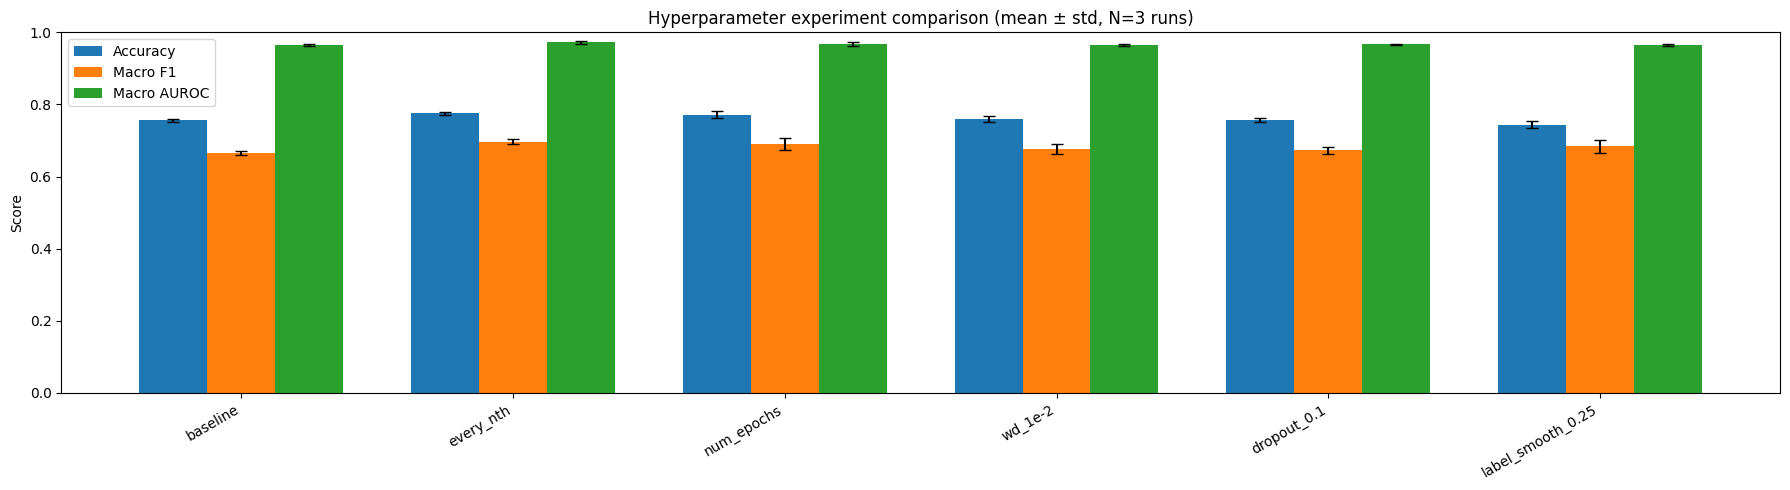

In [ ]:
'''
Print summary table and plot comparisons across configs (mean ± std over N_RUNS runs)
'''

# ── Summary table
col = 58
print(f"{'Config':<22} {'Accuracy':>16} {'Macro-F1':>16} {'Macro-AUROC':>16}")
print("-" * 72)
for r in exp_results:
    print(f"{r['name']:<22}"
          f"  {r['acc_mean']:.4f} ±{r['acc_std']:.4f}"
          f"  {r['f1_mean']:.4f} ±{r['f1_std']:.4f}"
          f"  {r['auroc_mean']:.4f} ±{r['auroc_std']:.4f}")
print(f"\n(N_RUNS={N_RUNS} per config; std dev across runs)")

# ── Bar chart with error bars
names  = [r['name']       for r in exp_results]
accs   = [r['acc_mean']   for r in exp_results]
f1s    = [r['f1_mean']    for r in exp_results]
aucs   = [r['auroc_mean'] for r in exp_results]
accs_e = [r['acc_std']    for r in exp_results]
f1s_e  = [r['f1_std']     for r in exp_results]
aucs_e = [r['auroc_std']  for r in exp_results]

x = np.arange(len(names))
w = 0.25
fig, ax = plt.subplots(figsize=(max(10, 3.0 * len(names)), 5))
ax.bar(x - w, accs,  w, yerr=accs_e,  capsize=4, label='Accuracy')
ax.bar(x,     f1s,   w, yerr=f1s_e,   capsize=4, label='Macro F1')
ax.bar(x + w, aucs,  w, yerr=aucs_e,  capsize=4, label='Macro AUROC')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title(f'Hyperparameter experiment comparison (mean ± std, N={N_RUNS} runs)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'hyp_exp_bar.png'), dpi=150)
plt.show()

# Evaluate Model

In [ ]:
'''
Collect training results
'''

import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score
)
import torch.nn.functional as F

model.eval()

all_labels  = []
all_preds   = []
all_probs   = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs   = F.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds  = np.concatenate(all_preds)
all_probs  = np.concatenate(all_probs)

print(f"Test frames evaluated : {len(all_labels):,}")
print(f"Overall accuracy      : {(all_labels == all_preds).mean():.4f}")

Test frames evaluated : 4,808
Overall accuracy      : 0.7510


In [ ]:
'''
accuracy, F1, and AUROC
'''

per_class_auroc = roc_auc_score(
    all_labels, all_probs,
    multi_class='ovr', average=None
)

per_class_f1 = f1_score(all_labels, all_preds, average=None)

cm = confusion_matrix(all_labels, all_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print(f"{'Idx':<4} {'Label':<10} {'Full Name':<42} {'Acc':>6} {'F1':>6} {'AUROC':>6}")
print("-" * 76)
for i in range(NUM_CLASSES):
    label = idx2label[i]
    print(
        f"{i:<4} {label:<10} {mapping[label]:<42} "
        f"{per_class_acc[i]:>6.3f} {per_class_f1[i]:>6.3f} {per_class_auroc[i]:>6.3f}"
    )

print("-" * 76)
macro_f1    = f1_score(all_labels, all_preds, average='macro')
macro_auroc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
overall_acc = (all_labels == all_preds).mean()
print(f"{'MACRO':>56} {overall_acc:>6.3f} {macro_f1:>6.3f} {macro_auroc:>6.3f}")

Idx  Label      Full Name                                     Acc     F1  AUROC
----------------------------------------------------------------------------
0    3T3        Albino Swiss Mouse Embryo                   0.865  0.892  0.992
1    A-10       Embryonic Rat Thoracic Aorta Medial Layer   0.994  0.986  1.000
2    A-549      Male Human Lung Carcinoma                   0.083  0.143  0.946
3    APM        African Water Mongoose Skin                 0.995  0.906  0.999
4    BPAE       Bovine Pulmonary Artery                     0.782  0.815  0.990
5    CRE-BAG2   Albino Swiss Mouse Embryo Moloney Murine Leukemia Virus Transfected Cells  0.598  0.626  0.918
6    CV-1       Normal African Green Monkey Kidney          0.978  0.707  0.999
7    LLC-MK2    Rhesus Monkey Kidney                        0.704  0.759  0.979
8    MDBK       Madin-Darby Bovine Kidney                   0.894  0.660  0.956
9    MDOK       Madin-Darby Ovine Kidney                    0.973  0.979  1.000
10   OK     

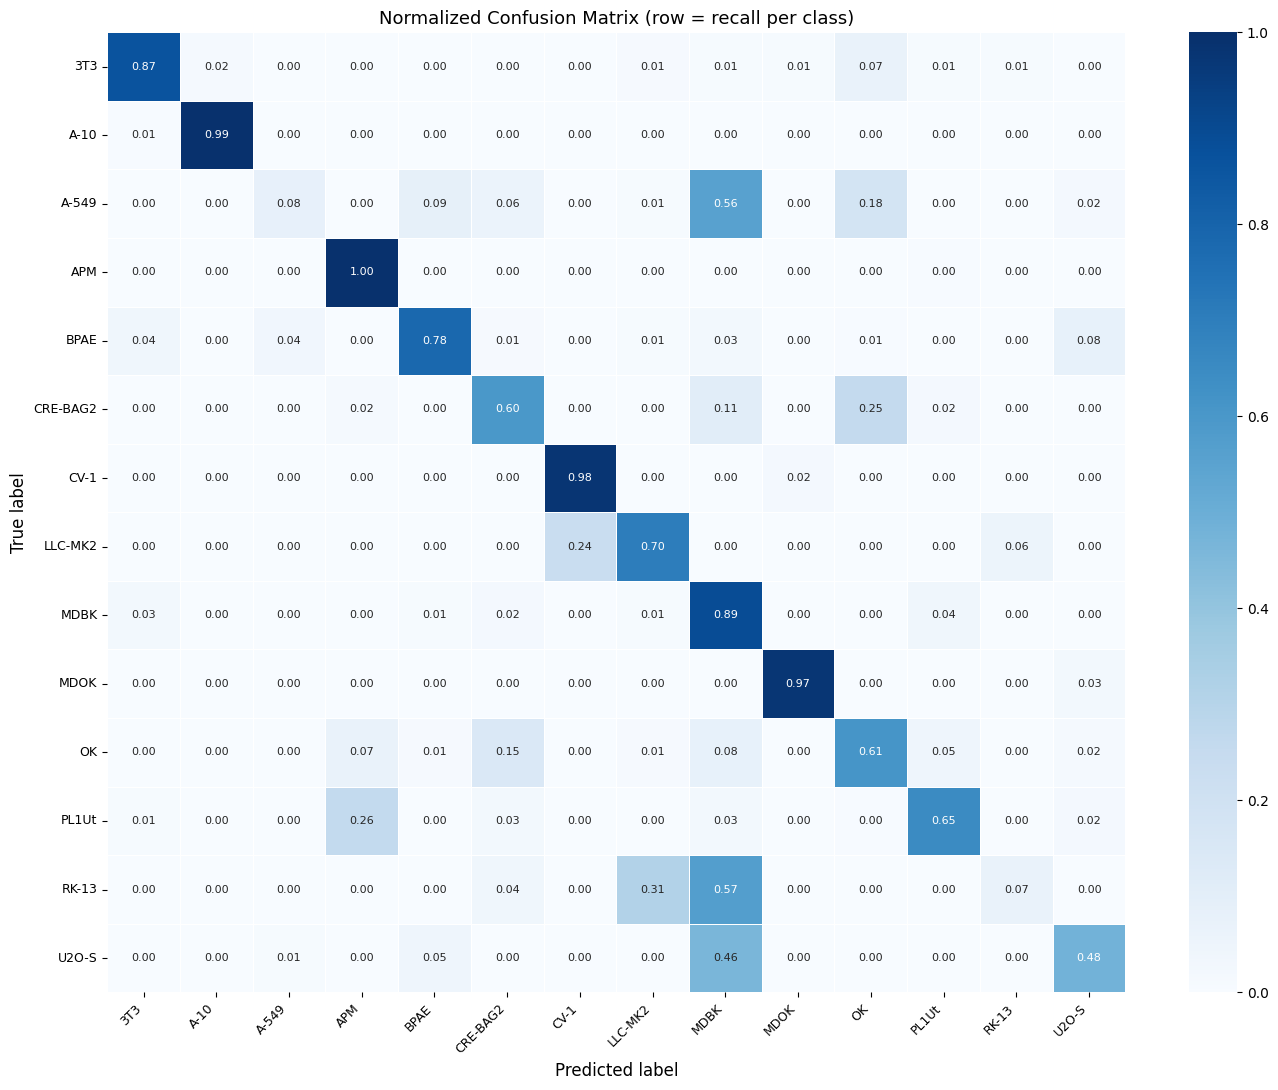

In [ ]:
'''
confusion matrix
'''
import matplotlib.pyplot as plt
import seaborn as sns

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

tick_labels = [idx2label[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f",
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    cmap="Blues",
    vmin=0, vmax=1,
    linewidths=0.4,
    ax=ax,
    annot_kws={"size": 8}
)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label",      fontsize=12)
ax.set_title("Normalized Confusion Matrix (row = recall per class)", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

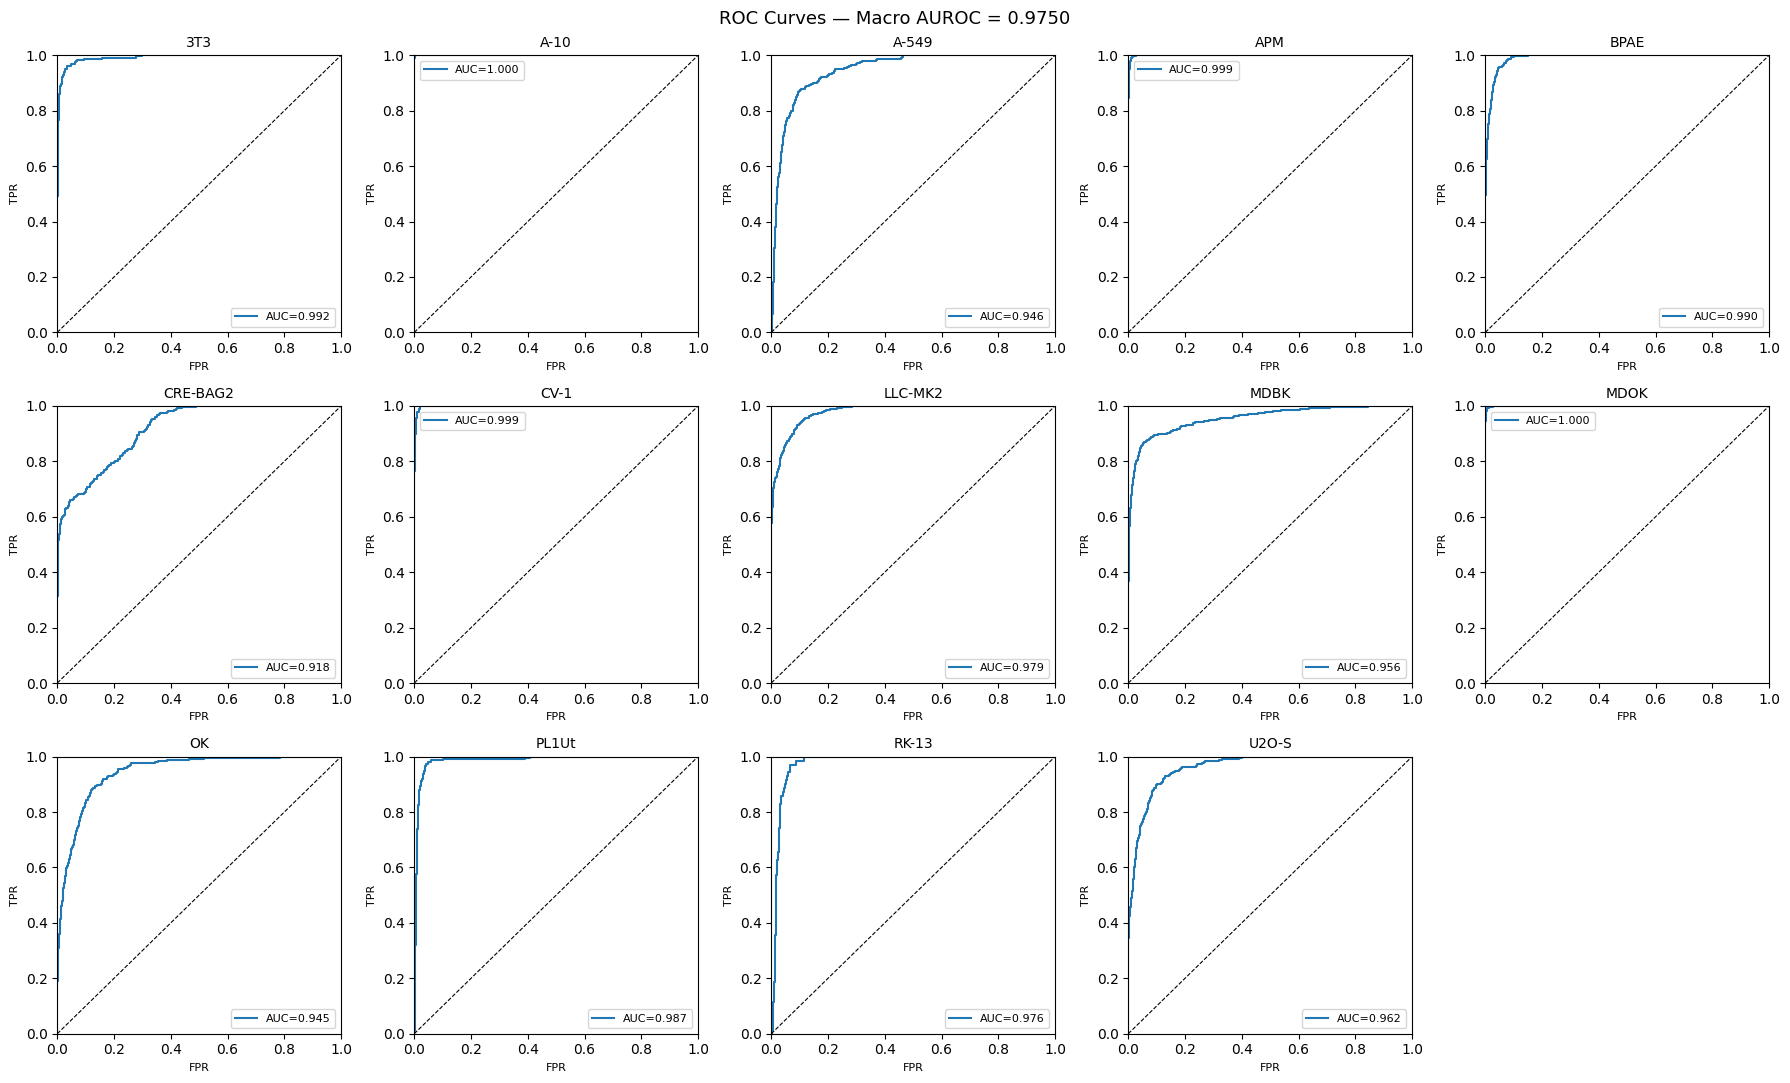

In [ ]:
'''
AUROC Curves
'''
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    axes[i].plot(fpr, tpr, lw=1.5, label=f"AUC={per_class_auroc[i]:.3f}")
    axes[i].plot([0,1],[0,1], 'k--', lw=0.8)
    axes[i].set_title(idx2label[i], fontsize=10)
    axes[i].set_xlabel("FPR", fontsize=8)
    axes[i].set_ylabel("TPR", fontsize=8)
    axes[i].legend(fontsize=8)
    axes[i].set_xlim([0,1])
    axes[i].set_ylim([0,1])

# Hide the two unused subplots (3x5 grid = 15, we have 14 classes)
axes[14].axis('off')

plt.suptitle(f"ROC Curves — Macro AUROC = {macro_auroc:.4f}", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "roc_curves.png"), dpi=150)
plt.show()

# Frozen Backbone Baseline

As a stronger baseline than majority-class, we train only the classification head
on top of a frozen pretrained ResNet18 backbone — i.e. the ImageNet weights are
never updated. This tells us how well off-the-shelf pretrained features perform
on our cell classification task without any fine-tuning, and lets us measure how
much the fine-tuning step in our main model actually contributes.

In [ ]:
'''
Frozen backbone baseline: train only the classification head, backbone frozen.
'''

import torch.nn.functional as F
from sklearn.metrics import f1_score, roc_auc_score

# ── Build frozen model and train
frozen_model = build_model(freeze_backbone=True)

frozen_criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
frozen_optimizer = optim.Adam(frozen_model.fc.parameters(),
                              lr=LR_HEAD, weight_decay=1e-4)
frozen_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    frozen_optimizer, T_max=NUM_EPOCHS)

frozen_ckpt = os.path.join(CHECKPOINT_DIR, 'frozen_baseline.pt')
best_frozen_acc = 0.0

print('Training frozen backbone baseline...')
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(frozen_model, train_loader,
                                  frozen_criterion, frozen_optimizer)
    te_loss, te_acc = eval_epoch(frozen_model, test_loader, frozen_criterion)
    frozen_scheduler.step()
    if te_acc > best_frozen_acc:
        best_frozen_acc = te_acc
        torch.save(frozen_model.state_dict(), frozen_ckpt)
        flag = '  ✓'
    else:
        flag = ''
    print(f'  Epoch {epoch:02d}/{NUM_EPOCHS}'
          f'  train {tr_acc:.3f}  test {te_acc:.3f}{flag}')

# ── Evaluate frozen model
frozen_model.load_state_dict(torch.load(frozen_ckpt, map_location=DEVICE))
frozen_model.eval()
frz_labels, frz_preds, frz_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        out  = frozen_model(imgs)
        frz_labels.append(labels.cpu().numpy())
        frz_preds.append(out.argmax(1).cpu().numpy())
        frz_probs.append(F.softmax(out, dim=1).cpu().numpy())
frz_labels = np.concatenate(frz_labels)
frz_preds  = np.concatenate(frz_preds)
frz_probs  = np.concatenate(frz_probs)

frz_acc  = (frz_labels == frz_preds).mean()
frz_f1   = f1_score(frz_labels, frz_preds, average='macro')
frz_auc  = roc_auc_score(frz_labels, frz_probs, multi_class='ovr', average='macro')

# ── Majority class baseline (kept for reference)
majority_class = np.bincount(all_labels).argmax()
majority_acc   = (all_labels == majority_class).mean()

# ── Comparison table
our_acc  = (all_labels == all_preds).mean()
our_f1   = f1_score(all_labels, all_preds, average='macro')
our_auc  = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

print(f"\n{'Model':<25} {'Accuracy':>9} {'Macro-F1':>10} {'Macro-AUROC':>13}")
print('-' * 60)
print(f"{'Majority class':<25} {majority_acc:>9.4f} {'—':>10} {'—':>13}")
print(f"{'Frozen backbone':<25} {frz_acc:>9.4f} {frz_f1:>10.4f} {frz_auc:>13.4f}")
print(f"{'Fine-tuned (ours)':<25} {our_acc:>9.4f} {our_f1:>10.4f} {our_auc:>13.4f}")
print(f"\nGain over frozen baseline:  acc +{our_acc - frz_acc:.4f}  "
      f"F1 +{our_f1 - frz_f1:.4f}  AUROC +{our_auc - frz_auc:.4f}")


Training frozen backbone baseline...
  Epoch 01/20  train 0.286  test 0.473  ✓
  Epoch 02/20  train 0.530  test 0.545  ✓
  Epoch 03/20  train 0.598  test 0.526
  Epoch 04/20  train 0.630  test 0.555  ✓
  Epoch 05/20  train 0.655  test 0.578  ✓
  Epoch 06/20  train 0.664  test 0.586  ✓
  Epoch 07/20  train 0.677  test 0.582
  Epoch 08/20  train 0.663  test 0.606  ✓
  Epoch 09/20  train 0.677  test 0.599
  Epoch 10/20  train 0.687  test 0.605
  Epoch 11/20  train 0.689  test 0.616  ✓
  Epoch 12/20  train 0.687  test 0.615
  Epoch 13/20  train 0.690  test 0.609
  Epoch 14/20  train 0.688  test 0.600
  Epoch 15/20  train 0.699  test 0.613
  Epoch 16/20  train 0.690  test 0.609
  Epoch 17/20  train 0.702  test 0.620  ✓
  Epoch 18/20  train 0.696  test 0.619
  Epoch 19/20  train 0.701  test 0.611
  Epoch 20/20  train 0.700  test 0.615

Model                      Accuracy   Macro-F1   Macro-AUROC
------------------------------------------------------------
Majority class               0.1215 

# Density Analysis

The CTMC challenge noted that classification difficulty correlates with frame density
(cells per frame). We stratify our test-set predictions into three density groups —
**low** (< 10 cells/frame), **medium** (10–20), and **high** (> 20) — using the
per-class average densities reported in the original challenge paper, and compare
accuracy, macro F1, and macro AUROC across groups.

Density group           N  Accuracy   Macro F1   Macro AUROC
------------------------------------------------------------
low (<10)            1225    0.7339     0.6539        0.9999
medium (10-20)       2552    0.7900     0.8099        0.9885
high (>20)           1031    0.6751     0.7352        0.9009


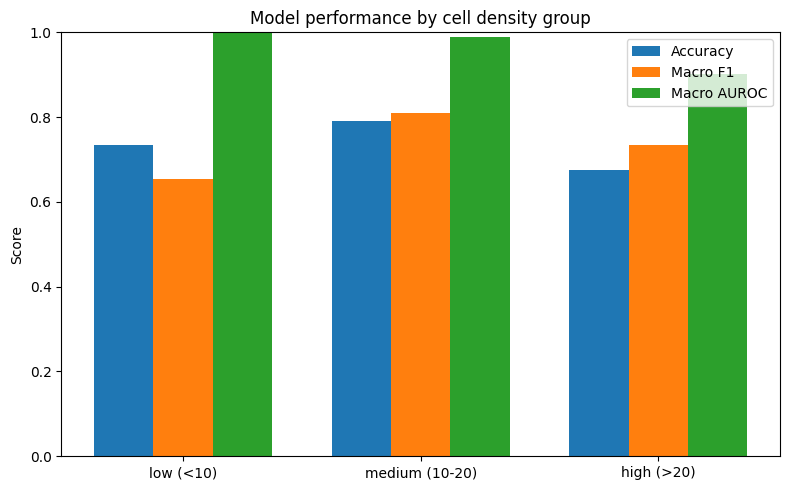


Per-class detail:
Label       Density Group                 Acc     F1  AUROC
--------------------------------------------------------------
3T3           13.12 medium (10-20)      0.865  0.892  0.992
A-10           7.97 low (<10)           0.994  0.986  1.000
A-549          9.93 low (<10)           0.083  0.143  0.946
APM            6.10 low (<10)           0.995  0.906  0.999
BPAE          27.88 high (>20)          0.782  0.815  0.990
CRE-BAG2      21.45 high (>20)          0.598  0.626  0.918
CV-1           3.42 low (<10)           0.978  0.707  0.999
LLC-MK2       10.76 medium (10-20)      0.704  0.759  0.979
MDBK          14.31 medium (10-20)      0.894  0.660  0.956
MDOK          11.84 medium (10-20)      0.973  0.979  1.000
OK            20.13 high (>20)          0.610  0.579  0.945
PL1Ut         12.55 medium (10-20)      0.652  0.696  0.987
RK-13          8.64 low (<10)           0.071  0.104  0.976
U2O-S         16.22 medium (10-20)      0.482  0.593  0.962


In [ ]:
'''
Density analysis: stratify test results by per-class average cell density
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score

# Per-class average densities (cells/frame) from the CTMC-v1 challenge paper (Table 1).
# These are the ground-truth annotation counts averaged over all frames per cell line.
CLASS_DENSITY = {
    "3T3":     13.12,
    "A-10":     7.97,
    "A-549":    9.93,
    "APM":      6.10,
    "BPAE":    27.88,
    "CRE-BAG2":21.45,
    "CV-1":     3.42,
    "LLC-MK2": 10.76,
    "MDBK":    14.31,
    "MDOK":    11.84,
    "OK":      20.13,
    "PL1Ut":   12.55,
    "RK-13":    8.64,
    "U2O-S":   16.22,
}

# Map each class index to its density group
def density_group(label_idx):
    label = idx2label[label_idx]
    d = CLASS_DENSITY[label]
    if d < 10:
        return 'low (<10)'
    elif d <= 20:
        return 'medium (10-20)'
    else:
        return 'high (>20)'

# Assign each test sample to a group
groups = np.array([density_group(l) for l in all_labels])
group_order = ['low (<10)', 'medium (10-20)', 'high (>20)']

print(f"{'Density group':<18} {'N':>6} {'Accuracy':>9} {'Macro F1':>10} {'Macro AUROC':>13}")
print("-" * 60)

density_results = {}
for g in group_order:
    mask = groups == g
    if mask.sum() == 0:
        print(f"{g:<18} {'0':>6}  (no samples)")
        continue
    g_labels = all_labels[mask]
    g_preds  = all_preds[mask]
    g_probs  = all_probs[mask]

    g_acc  = (g_labels == g_preds).mean()
    # Only compute F1/AUROC if more than one class is present in the group
    present = np.unique(g_labels)
    if len(present) > 1:
        g_f1   = f1_score(g_labels, g_preds, average='macro', labels=present, zero_division=0)
        g_probs_present = g_probs[:, present]
        g_probs_present = g_probs_present / g_probs_present.sum(axis=1, keepdims=True)
        g_auc  = roc_auc_score(
            g_labels, g_probs_present,
            multi_class='ovr', average='macro',
            labels=present
        )
    else:
        g_f1, g_auc = float('nan'), float('nan')

    density_results[g] = {"acc": g_acc, "f1": g_f1, "auroc": g_auc, "n": mask.sum()}
    print(f"{g:<18} {mask.sum():>6} {g_acc:>9.4f} {g_f1:>10.4f} {g_auc:>13.4f}")

# ── Bar chart
valid_groups = [g for g in group_order if g in density_results]
x = np.arange(len(valid_groups))
w = 0.25
accs_d  = [density_results[g]['acc']   for g in valid_groups]
f1s_d   = [density_results[g]['f1']    for g in valid_groups]
aucs_d  = [density_results[g]['auroc'] for g in valid_groups]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, accs_d, w, label='Accuracy')
ax.bar(x,     f1s_d,  w, label='Macro F1')
ax.bar(x + w, aucs_d, w, label='Macro AUROC')
ax.set_xticks(x)
ax.set_xticklabels(valid_groups)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model performance by cell density group')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'density_analysis.png'), dpi=150)
plt.show()

# ── Per-class density breakdown
print("\nPer-class detail:")
print(f"{'Label':<10} {'Density':>8} {'Group':<18} {'Acc':>6} {'F1':>6} {'AUROC':>6}")
print("-" * 62)
for i in range(NUM_CLASSES):
    label = idx2label[i]
    d     = CLASS_DENSITY[label]
    grp   = density_group(i)
    mask  = all_labels == i
    if mask.sum() == 0:
        continue
    cl_acc = (all_labels[mask] == all_preds[mask]).mean()
    print(f"{label:<10} {d:>8.2f} {grp:<18} {cl_acc:>6.3f} "
          f"{per_class_f1[i]:>6.3f} {per_class_auroc[i]:>6.3f}")